# Previsão de Receita de Compradores Online

# 1. Visão Geral do Projeto

Este projeto desenvolve um modelo de machine learning para prever se um cliente online gerará receita (fará uma compra) com base no comportamento de navegação e nas informações da sessão. Utilizando o dataset "Online Shoppers Intention",

Este é um problema de classificação binária em que classificamos uma sessão como:

- **Positivo (True)**: o usuário realizou uma compra.

- **Negativo (False)**: o usuário não realizou uma compra.

# 2. Dataset


The project uses the ``Online Shoppers Intention``  [[1]](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) 
dataset, which contains information about user sessions on an e-commerce website. Each session is labeled with whether it resulted in a purchase (Revenue = TRUE) or not (Revenue = FALSE).


###  Dataset Characteristics
- **Type**: Multivariate dataset
- **Subject Area**: Business/E-commerce
- **Associated Tasks**: Classification, Clustering
- **Data Quality**: No missing values, clean dataset

### Feature Set
**Total Features**: 18 attributes (17 features + 1 target)

#### **Numerical Features (10)**
1. **Administrative** - Count of administrative pages visited 
2. **Administrative_Duration** - Time spent on administrative pages
3. **Informational** - Count of informational pages visited 
4. **Informational_Duration** - Time spent on informational pages
5. **ProductRelated** - Count of product-related pages visited 
6. **ProductRelated_Duration** - Time spent on product-related pages 
7. **BounceRates** - Percentage of visitors who enter and leave without interaction
8. **ExitRates** - Percentage of pageviews that were the last in the session 
9. **PageValues** - Average value for web pages before completing e-commerce transaction
10. **SpecialDay** - Closeness to special days

#### **Categorical Features (8)**
1. **Operating System** - Visitor's operating system 
2. **Browser** - Web browser used 
3. **Region** - Geographical region of visitor 
4. **Traffic Type** - Traffic source type 
5. **Visitor Type** - New or returning visitor
6. **Weekend** - Weekend visit indicator 
7. **Month** - Month of session occurrence 

#### **Target Variable**
- **Revenue** - Session outcome indicator 
  - `True`: Session ended with shopping transaction
  - `False`: Session did not end with shopping transaction

### Class Distribution
- **Total Sessions**: 12,330
- **Negative Class (No Purchase)**: 10,422 sessions (84.5%)
- **Positive Class (Purchase)**: 1,908 sessions (15.5%)
- **Class Imbalance Ratio**: 5.46:1 (Imbalanced dataset)


# 3. Exploração dos Dados

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3.1 Carregamento dos Dados e Informações Básicas

In [21]:
df=pd.read_csv(r"C:\Users\denil\Documents\GitHub\Machine_learning_Docker_Fiap\data\raw\online_shoppers_intention.csv")

print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")

Dataset shape: (12330, 18)
Number of samples: 12330


In [22]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [23]:
print("Dataset Info:")
print("=" * 50)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficT

## 3.2 Duplicatas e Valores Ausentes

In [24]:
missing_values = df.isnull().sum()
missing_values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## 3.3 Duplicatas

In [25]:
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows ({duplicates/len(df)*100:.2f}% of data)")
else:
    print("No duplicate rows found!")

Found 125 duplicate rows (1.01% of data)


In [26]:
df = df.drop_duplicates().reset_index(drop=True)
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [27]:
print(f"\nData types check:")
for col in df.columns:
    dtype = df[col].dtype
    unique_vals = df[col].nunique()
    print(f"  {col:<25}: {str(dtype):<10} ({unique_vals} unique values)")


Data types check:
  Administrative           : int64      (27 unique values)
  Administrative_Duration  : float64    (3335 unique values)
  Informational            : int64      (17 unique values)
  Informational_Duration   : float64    (1258 unique values)
  ProductRelated           : int64      (311 unique values)
  ProductRelated_Duration  : float64    (9551 unique values)
  BounceRates              : float64    (1872 unique values)
  ExitRates                : float64    (4777 unique values)
  PageValues               : float64    (2704 unique values)
  SpecialDay               : float64    (6 unique values)
  Month                    : object     (10 unique values)
  OperatingSystems         : int64      (8 unique values)
  Browser                  : int64      (13 unique values)
  Region                   : int64      (9 unique values)
  TrafficType              : int64      (20 unique values)
  VisitorType              : object     (3 unique values)
  Weekend                  :

## 3.4 Distribuição do Alvo

In [28]:
target_counts = df['Revenue'].value_counts()


print("Revenue Distribution:")
print("=" * 45)
print(f"FALSE (No Purchase): {target_counts[False]:,} ({(target_counts[False] /((target_counts[False]+target_counts[True])))*100:.2f}%)")
print(f"TRUE (Purchase):     {target_counts[True]:,} ({(target_counts[True] / (target_counts[True]+target_counts[False]))*100:.2f}%)")
print(f"\nClass Imbalance Ratio: {target_counts[False]/target_counts[True]:.2f}:1")

Revenue Distribution:
FALSE (No Purchase): 10,297 (84.37%)
TRUE (Purchase):     1,908 (15.63%)

Class Imbalance Ratio: 5.40:1


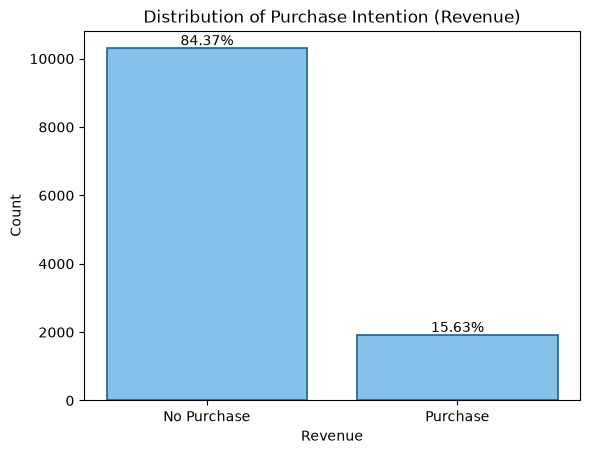

In [29]:
percentages=[f"{(target_counts[False] /((target_counts[False]+target_counts[True])))*100:.2f}%",f"{(target_counts[True] /((target_counts[False]+target_counts[True])))*100:.2f}%"]

bars=plt.bar(["No Purchase","Purchase"],target_counts,color="#85C1E9",edgecolor="#21618C",linewidth=1.2)

plt.bar_label(bars, labels=percentages,label_type='edge')
plt.ylabel("Count")
plt.xlabel("Revenue")
plt.title("Distribution of Purchase Intention (Revenue)")
plt.grid(False)
plt.show()

> Insight principal: o dataset está desbalanceado, com muito mais sessões sem compra do que com compra.

## 3.5 Análise das Features Numéricas

*   **Features numéricas:** `Administrative`, `Administrative_Duration`, `Informational`, `Informational_Duration`, `ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay`.
*   **Categóricas (necessitam de codificação):** `Month`, `VisitorType`.
*   **Categóricas:** `OperatingSystems`, `Browser`, `Region`, `TrafficType`, `Weekend`.
*   **Alvo:** `Revenue`.


In [30]:
# Statistical summary of numerical features
print("Statistical Summary of Numerical Features:")
print("=" * 80)
numerical_features = ['Administrative', 'Administrative_Duration', 'Informational', 
                      'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                      'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
df[numerical_features].describe()


Statistical Summary of Numerical Features:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


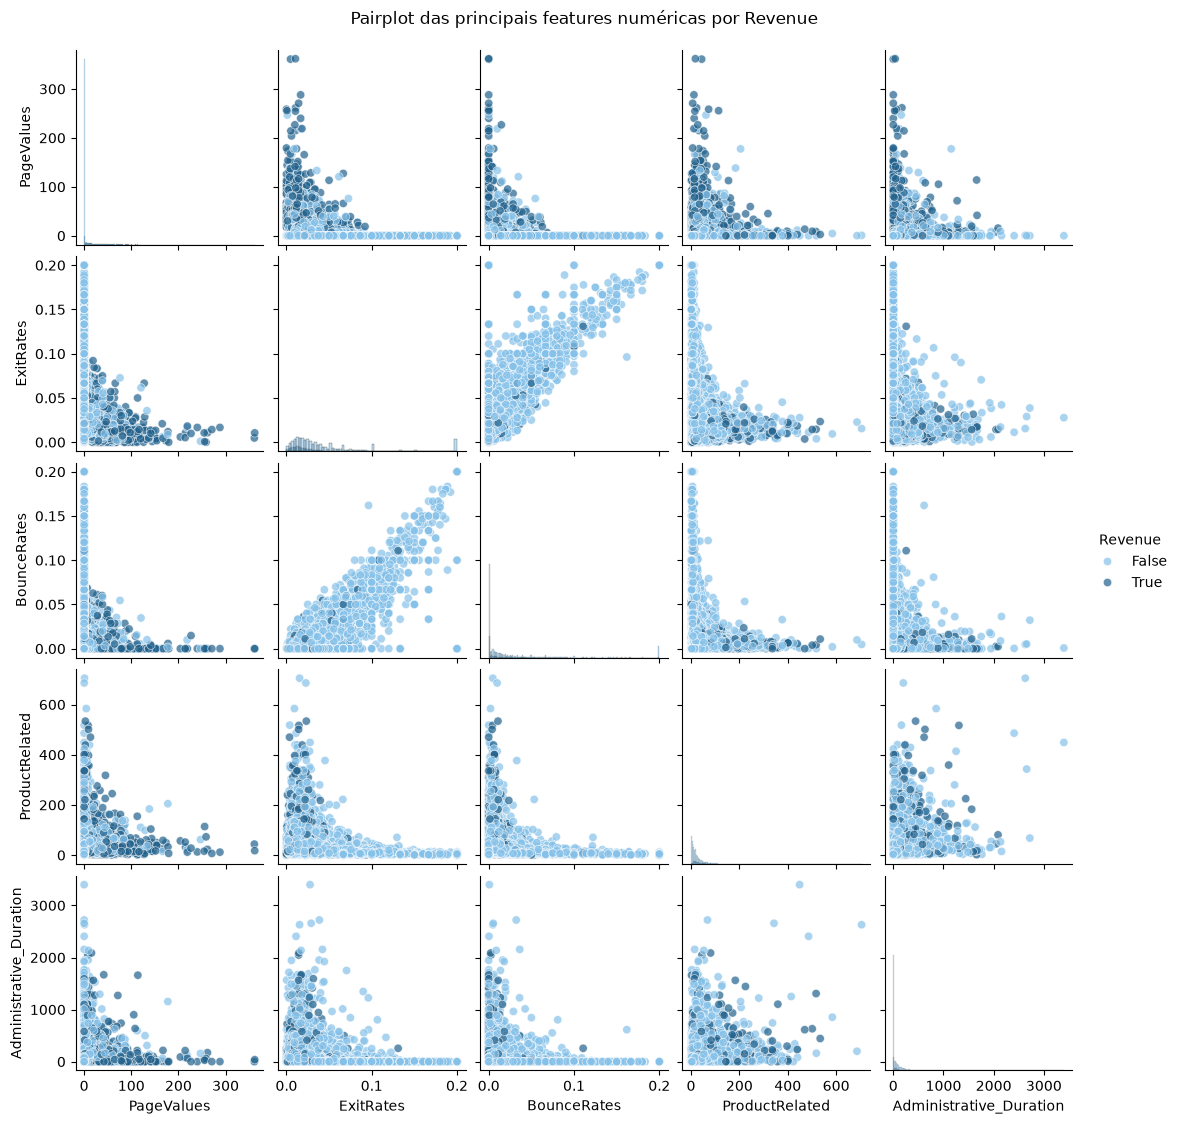

In [31]:
pair_vars = ['PageValues', 'ExitRates', 'BounceRates', 'ProductRelated', 'Administrative_Duration']

sns.pairplot(
    df[pair_vars + ['Revenue']],
    hue='Revenue',
    palette={False: '#85C1E9', True: '#21618C'},
    diag_kind='hist',
    height=2.2,
    plot_kws={'alpha': 0.7},
)
plt.suptitle('Pairplot das principais features numéricas por Revenue', y=1.02)
plt.show()


A maioria das features (como `ProductRelated` e `Administrative_Duration`) está **assimétrica à direita**. Isso significa que a maioria dos usuários navega em poucas páginas por pouco tempo, enquanto um pequeno grupo de usuários mais ativos navega muito mais.

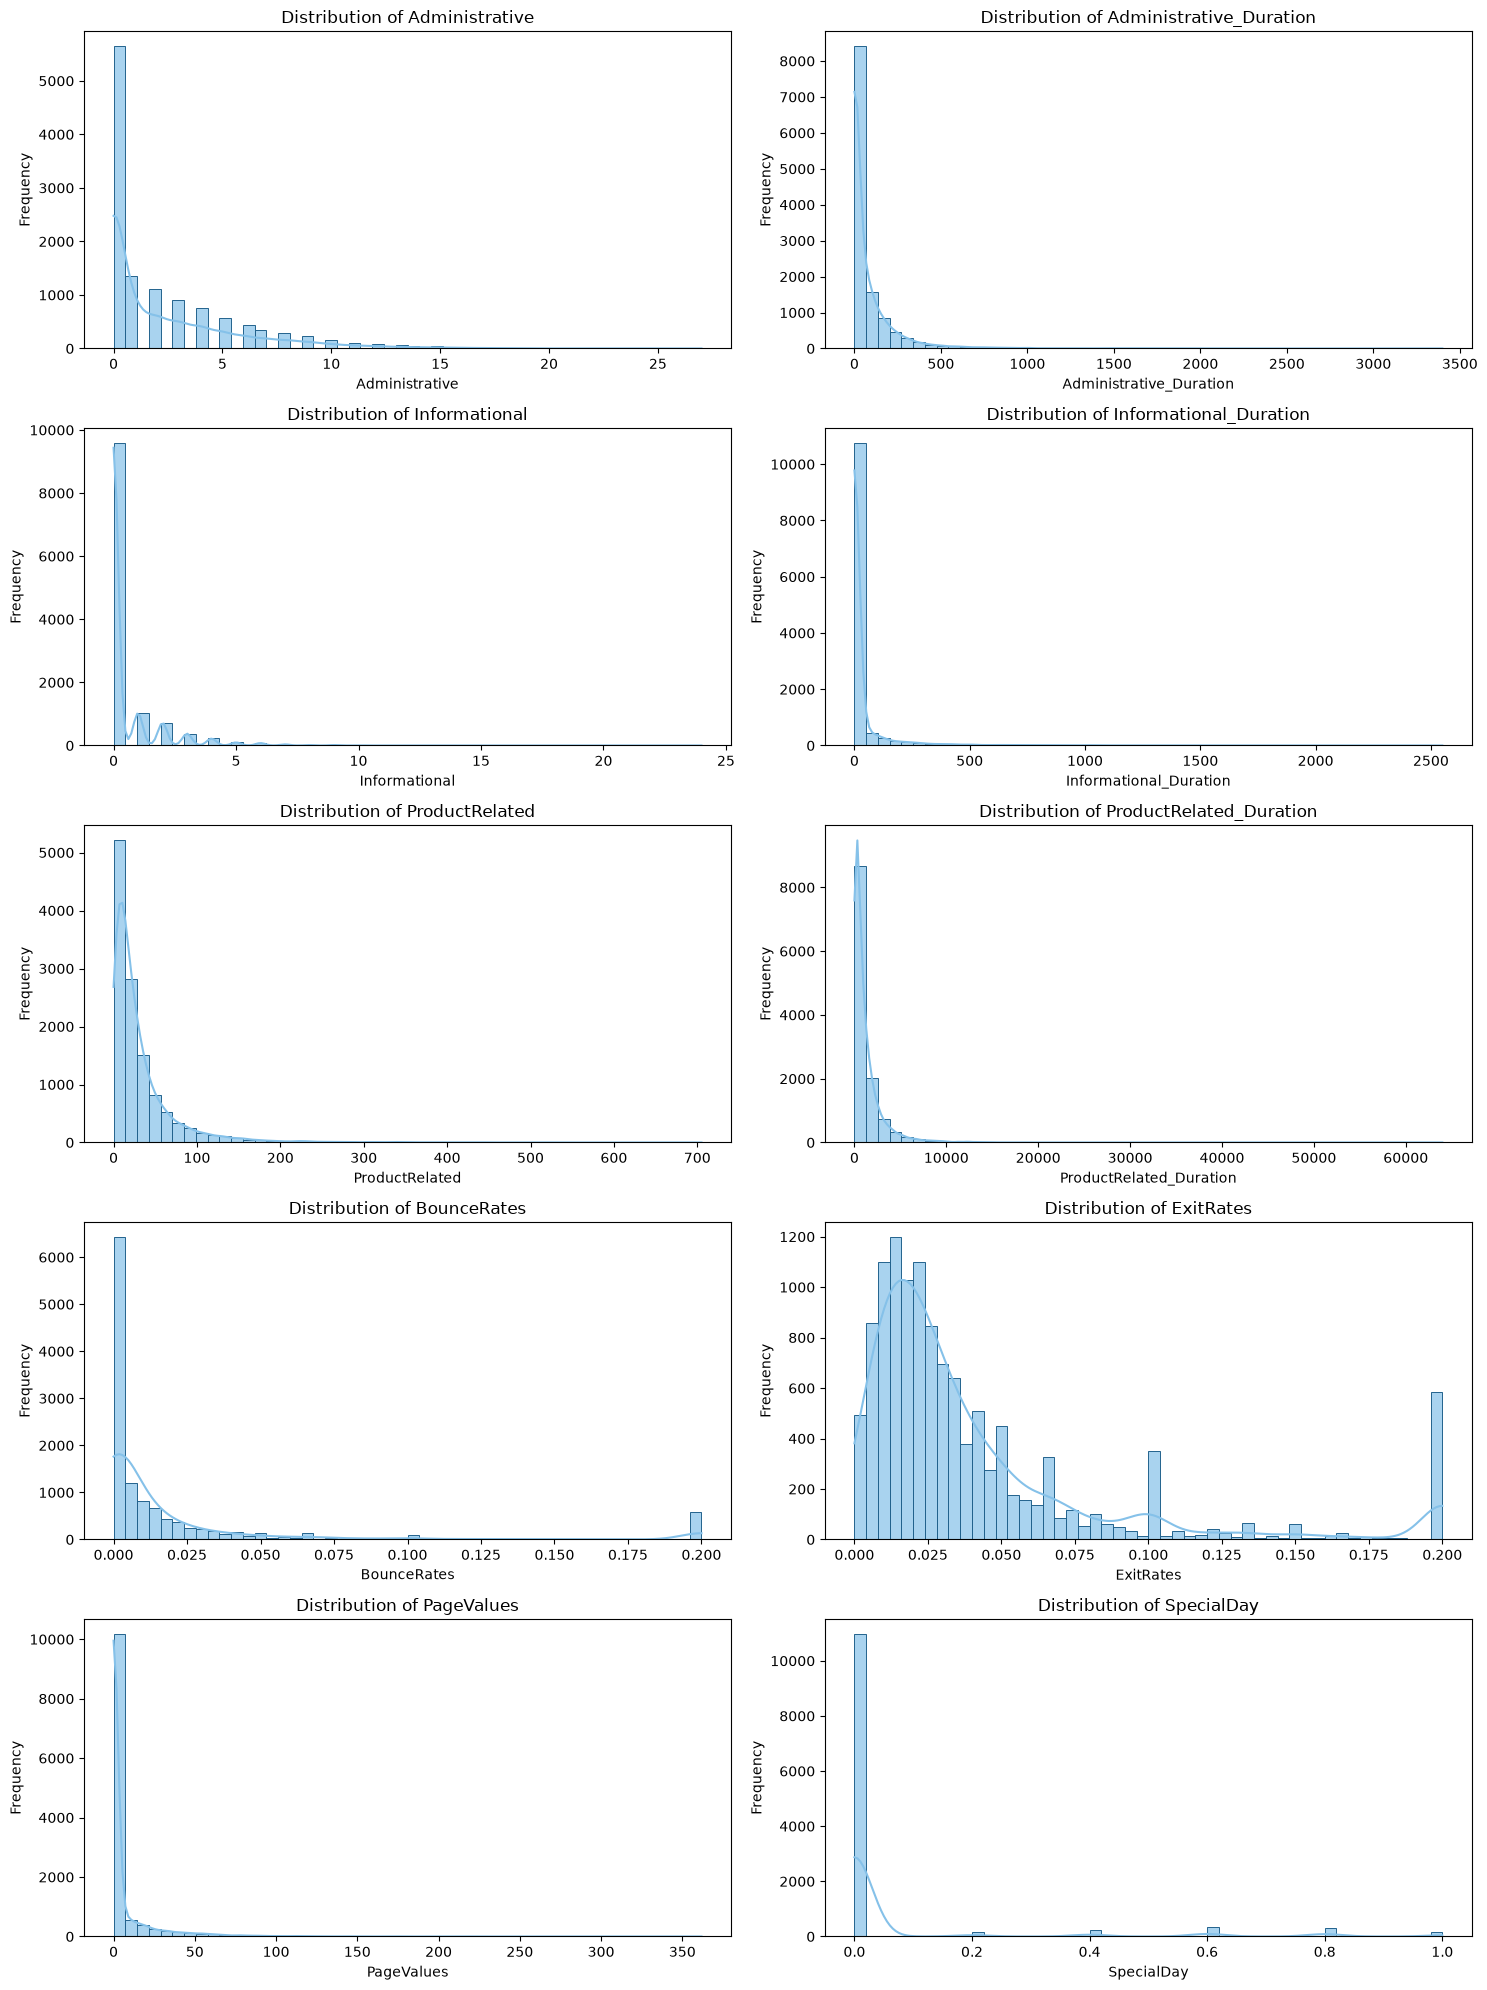

In [32]:
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    # O kde=True adiciona a linha de densidade por cima do histograma
    sns.histplot(df[col], bins=50, color='#85C1E9', edgecolor='#21618C', 
                 kde=True, ax=axes[idx], alpha=0.7)
    
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Correlation with Revenue:
Revenue                    1.000000
PageValues                 0.491894
ProductRelated             0.156042
ProductRelated_Duration    0.150077
Administrative             0.136330
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
SpecialDay                -0.083601
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64


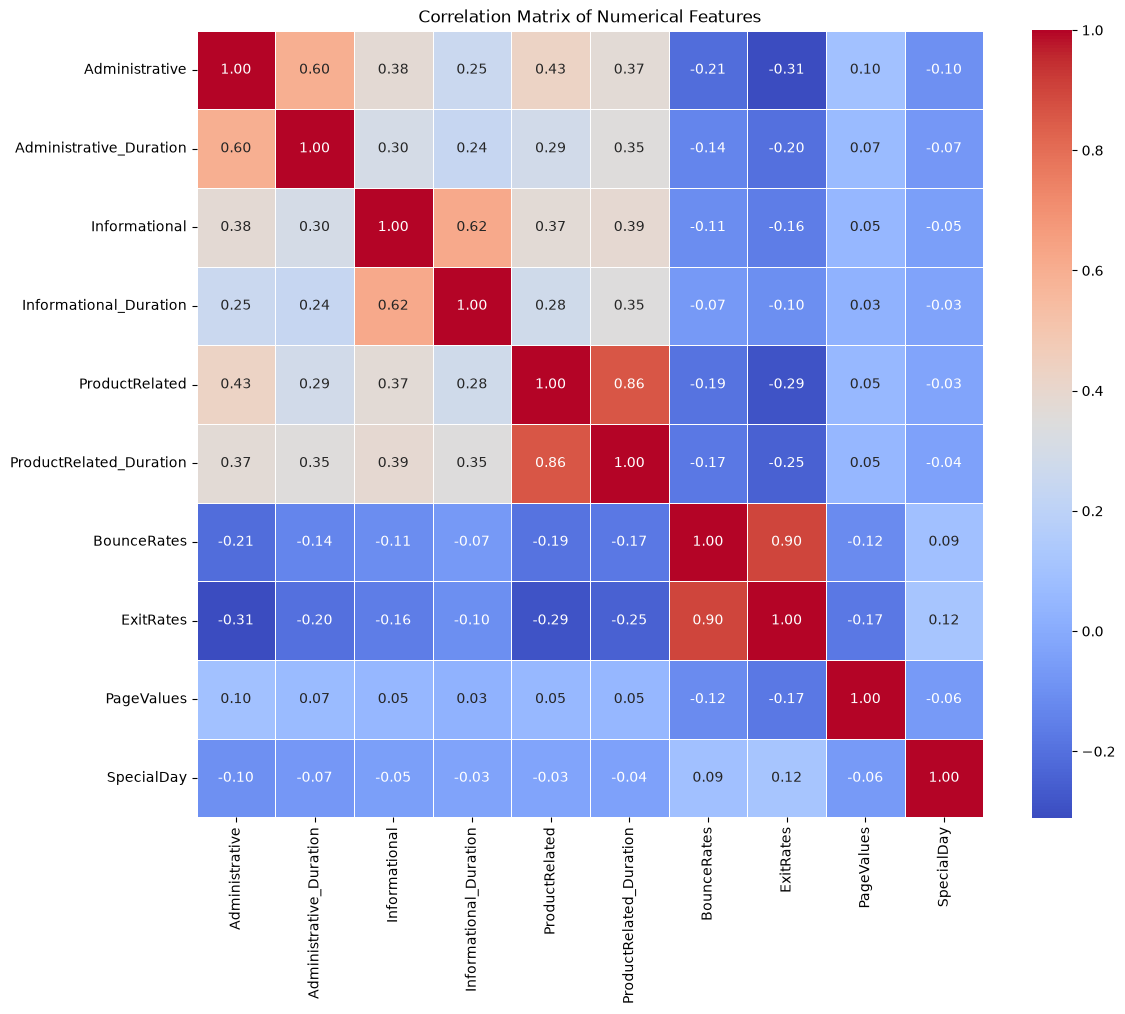

In [33]:
# Correlation Analysis

print("\nCorrelation with Revenue:")
print("=" * 50)
correlation_with_target = df[numerical_features + ['Revenue']].corr()['Revenue'].sort_values(ascending=False)
print(correlation_with_target)


plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

`PageValues` é a **feature mais importante** (correlação de 0,49). Ela é o melhor indicador de que alguém vai comprar. Em contraste, `ExitRates` e `BounceRates` apresentam correlação negativa: se as pessoas saem rapidamente, normalmente não compram.

## 3.6 Análise das Features Categóricas

In [34]:
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

categorical_features = ['Month', 'OperatingSystems', 'Browser', 'Region', 
                        'TrafficType', 'VisitorType', 'Weekend']

for feature in categorical_features:
    print(f"\n{feature} - Value Counts:")
    print(df[feature].value_counts())
    print("-" * 50)


CATEGORICAL FEATURES ANALYSIS

Month - Value Counts:
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64
--------------------------------------------------

OperatingSystems - Value Counts:
OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64
--------------------------------------------------

Browser - Value Counts:
Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64
--------------------------------------------------

Region - Value Counts:
Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64
--------------------------------------------------

TrafficType - Value Counts:
TrafficType
2     3911
1     2388
3     2013


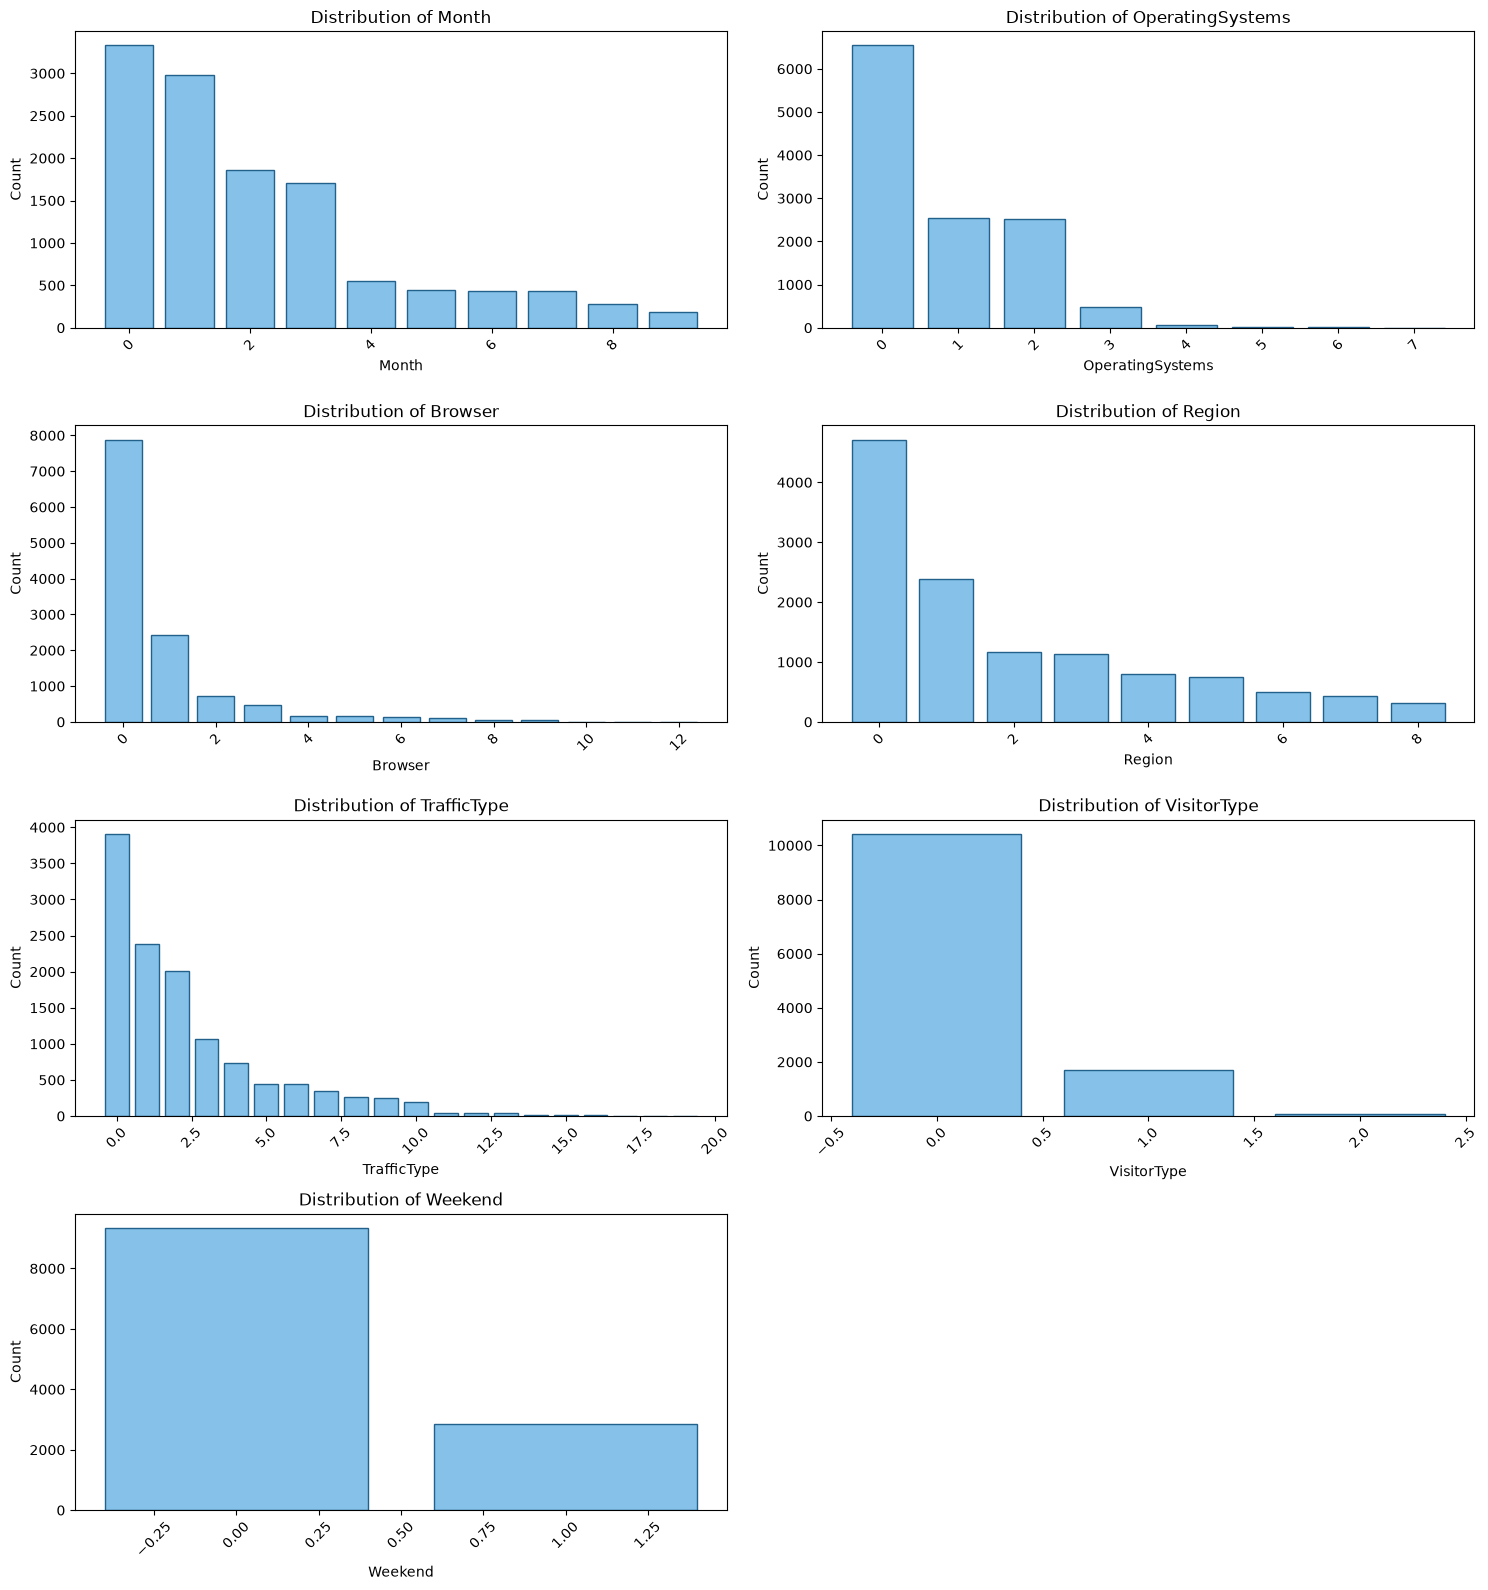

In [35]:
# Visualize categorical features
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, 
                  color='#85C1E9', edgecolor='#21618C')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(False)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

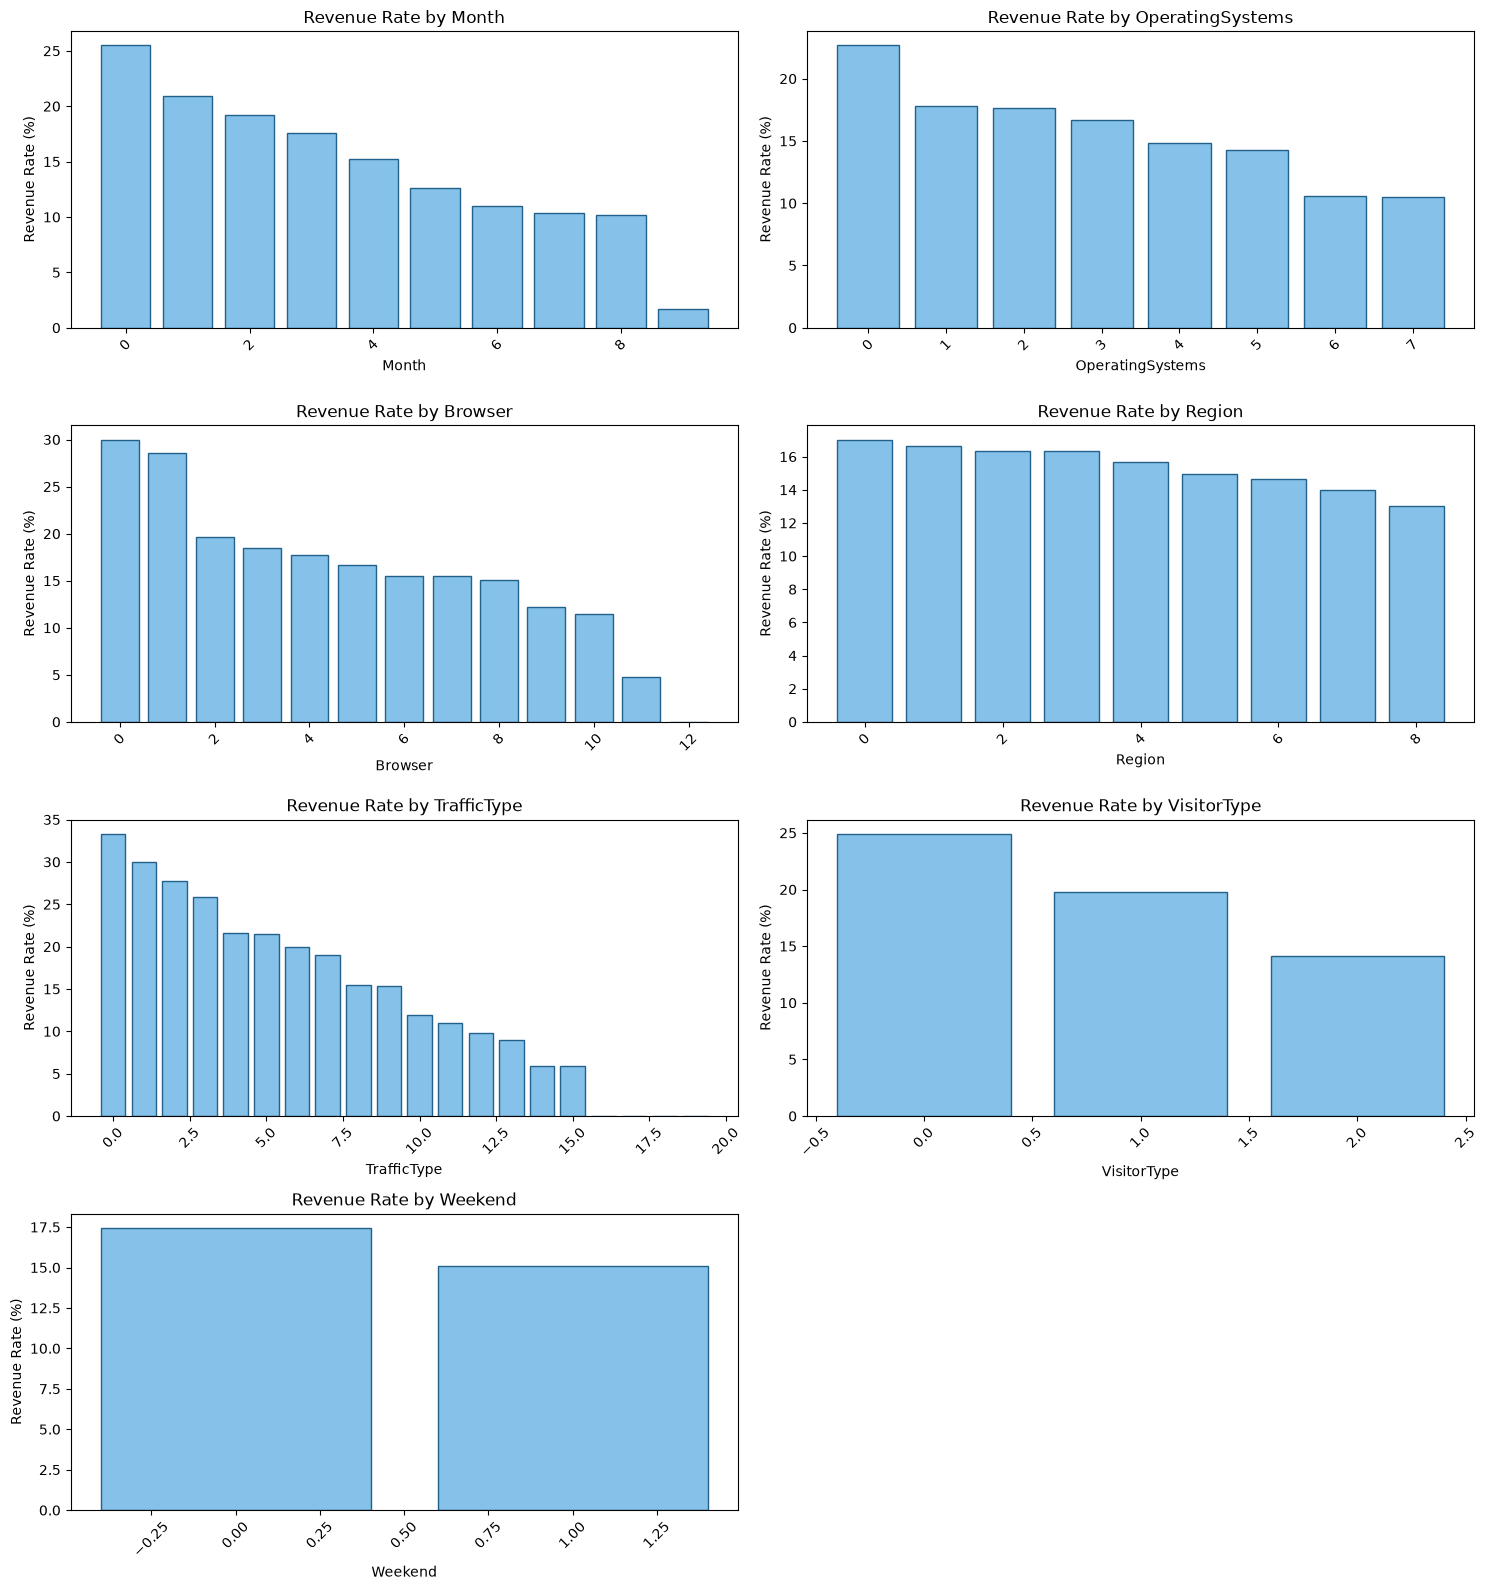

In [36]:
# Revenue rate by categorical features

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    revenue_rate = df.groupby(col)['Revenue'].mean().sort_values(ascending=False)
    axes[idx].bar(range(len(revenue_rate)), revenue_rate.values * 100,
                  color='#85C1E9', edgecolor='#21618C')
    axes[idx].set_title(f'Revenue Rate by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Revenue Rate (%)')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(False)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 4. Pré-processamento dos Dados

## 4.1 Codificação das Variáveis Categóricas

In [37]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


df_encoded = df.copy()

# Label encode binary/ordinal features
label_encoder = LabelEncoder()

# Encode Month 
month_order = {'Feb': 1, 'Mar': 2, 'May': 3, 'June': 4, 'Jul': 5, 
               'Aug': 6, 'Sep': 7, 'Oct': 8, 'Nov': 9, 'Dec': 10}
df_encoded['Month'] = df_encoded['Month'].map(month_order)

In [38]:
# VisitorType
df_encoded['VisitorType'] = label_encoder.fit_transform(df_encoded['VisitorType'])

In [39]:
# Weekend & Revenue
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

## 4.2 Feature and Target Separation

In [40]:
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

## 4.3 Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 9764 (80.0%)
Test set size: 2441 (20.0%)

Training set class distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Test set class distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


## 4.4 Feature Scaling

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

Scaled training set shape: (9764, 17)
Scaled test set shape: (2441, 17)


# 5. Model Training and Evaluation

## 5.1 Model Training

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

In [44]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Model': model
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")


Training Logistic Regression...
Logistic Regression - Accuracy: 0.8865, F1-Score: 0.5166, ROC-AUC: 0.8963

Training Decision Tree...
Decision Tree - Accuracy: 0.8591, F1-Score: 0.5509, ROC-AUC: 0.7342

Training Random Forest...
Random Forest - Accuracy: 0.9095, F1-Score: 0.6764, ROC-AUC: 0.9255


## 5.2 Model Comparison


Model Performance Summary:
                     Accuracy Precision    Recall  F1-Score   ROC-AUC
Random Forest        0.909463  0.767442  0.604712  0.676428  0.925487
Decision Tree        0.859074  0.549479  0.552356  0.550914  0.734167
Logistic Regression  0.886522  0.774869  0.387435  0.516579  0.896257


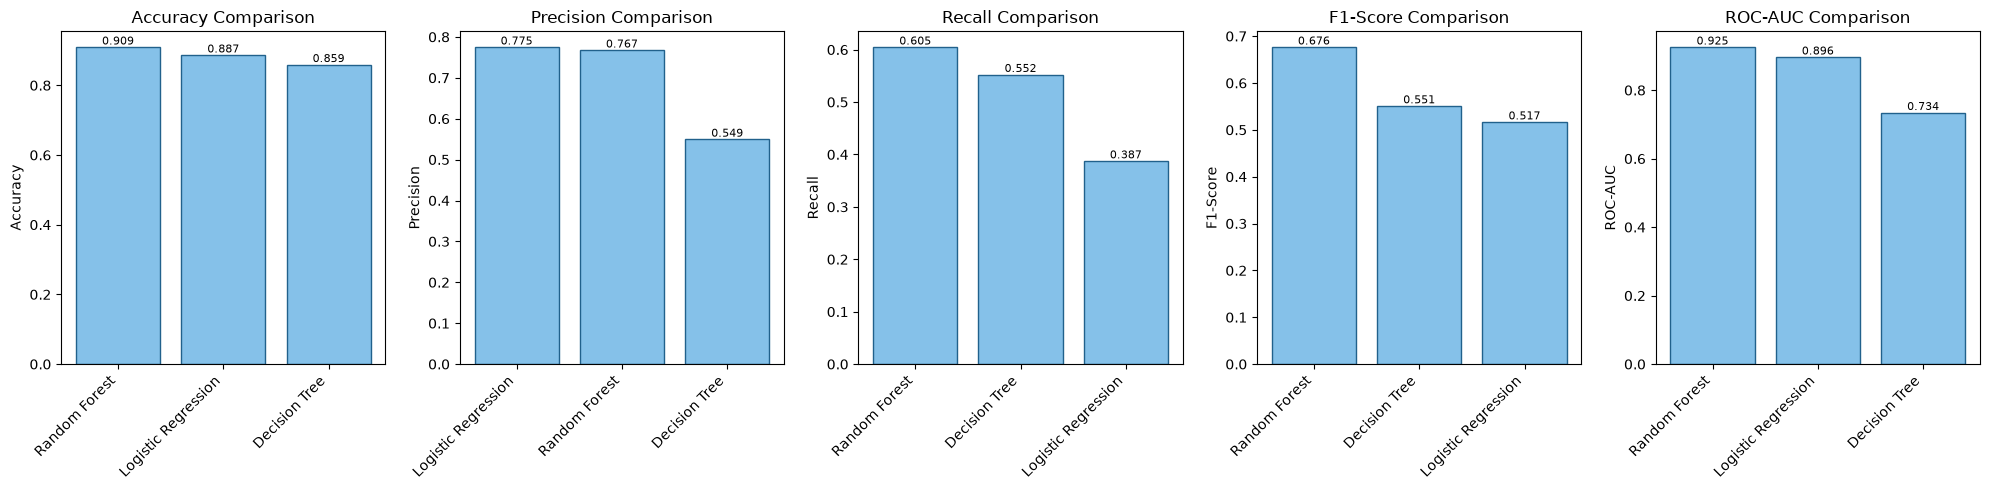

In [45]:
results_df = pd.DataFrame(results).T
results_df = results_df.drop('Model', axis=1)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\nModel Performance Summary:")
print(results_df)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

for idx, metric in enumerate(metrics):
    sorted_results = results_df.sort_values(metric, ascending=False)
    bars = axes[idx].bar(range(len(sorted_results)), sorted_results[metric], 
                         color='#85C1E9', edgecolor='#21618C')
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_ylabel(metric)
    axes[idx].set_xticks(range(len(sorted_results)))
    axes[idx].set_xticklabels(sorted_results.index, rotation=45, ha='right')
    axes[idx].grid(False)
    
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Random Forest** is the clear winner. It outperformed Logistic Regression and Decision Trees on almost every metric, specifically the F1-Score (which balances precision and recall) and ROC-AUC.

## 5.3 Best Model Analysis



Best Model: Random Forest
Best F1-Score: 0.6764


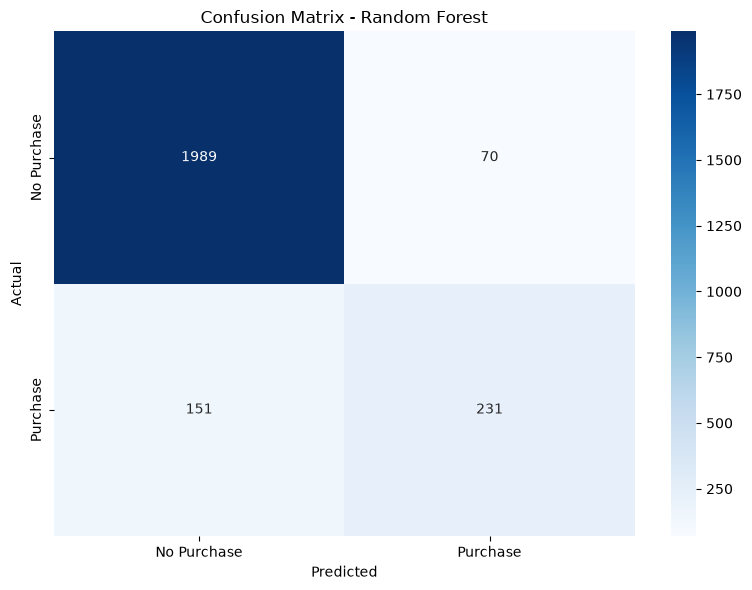


Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.93      0.97      0.95      2059
    Purchase       0.77      0.60      0.68       382

    accuracy                           0.91      2441
   macro avg       0.85      0.79      0.81      2441
weighted avg       0.90      0.91      0.90      2441



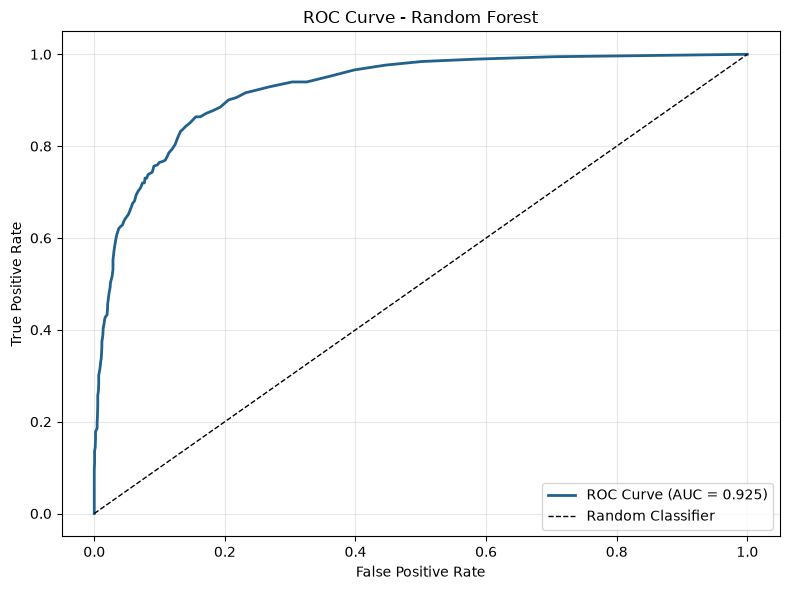

In [46]:
best_model_name = results_df.index[0]
best_model = results[best_model_name]['Model']

print(f"\nBest Model: {best_model_name}")
print(f"Best F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")

y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]


cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


print("\nClassification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred_best, 
                          target_names=['No Purchase', 'Purchase']))


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#21618C', linewidth=2, 
         label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba_best):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()